Name: James Fisher
Date: April 17, 2026
Course: DDS-8555 (Predictive Analytics)
Assignment: Week 8, House Prices Advanced Regression Techniques

In [37]:
# Load libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import ElasticNetCV, RidgeCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold, cross_val_score

# Set random state and cross-validation strategy
RANDOM_STATE = 123
N_SPLITS = 5
cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# Set display options
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

# Load data
train = pd.read_csv("data/house-prices/train.csv")
test = pd.read_csv("data/house-prices/test.csv")
sample_sub = pd.read_csv("data/house-prices/sample_submission.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_sub.shape)
display(train.head())

Train shape: (1460, 81)
Test shape: (1459, 80)
Sample submission shape: (1459, 2)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [38]:
# Separate target and predictors
y = np.log1p(train["SalePrice"])
X = train.drop(columns=["SalePrice"]).copy()
X_test = test.copy()

print("Target summary on original scale:")
display(train["SalePrice"].describe())

print("\nMissing values in train (top 20):")
display(train.isna().sum().sort_values(ascending=False).head(20))

Target summary on original scale:


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


Missing values in train (top 20):


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
dtype: int64

In [39]:
# Feature engineering helper
class AmesFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Numeric cleanup helpers
        for col in ["GarageYrBlt", "LotFrontage", "MasVnrArea", "BsmtFinSF1", "BsmtFinSF2",
                    "BsmtUnfSF", "TotalBsmtSF", "BsmtFullBath", "BsmtHalfBath", "GarageCars",
                    "GarageArea"]:
            if col in X.columns:
                X[col] = pd.to_numeric(X[col], errors="coerce")

        # Basic domain features
        X["HouseAge"] = X["YrSold"] - X["YearBuilt"]
        X["RemodAge"] = X["YrSold"] - X["YearRemodAdd"]
        X["IsRemodeled"] = (X["YearRemodAdd"] > X["YearBuilt"]).astype(int)
        X["IsNewHouse"] = (X["YrSold"] == X["YearBuilt"]).astype(int)

        X["TotalBath"] = (
            X["FullBath"].fillna(0)
            + 0.5 * X["HalfBath"].fillna(0)
            + X["BsmtFullBath"].fillna(0)
            + 0.5 * X["BsmtHalfBath"].fillna(0)
        )

        X["TotalPorchSF"] = (
            X["OpenPorchSF"].fillna(0)
            + X["EnclosedPorch"].fillna(0)
            + X["3SsnPorch"].fillna(0)
            + X["ScreenPorch"].fillna(0)
        )

        X["TotalSF"] = (
            X["1stFlrSF"].fillna(0)
            + X["2ndFlrSF"].fillna(0)
            + X["TotalBsmtSF"].fillna(0)
        )

        X["HasGarage"] = (X["GarageArea"].fillna(0) > 0).astype(int)
        X["HasBsmt"] = (X["TotalBsmtSF"].fillna(0) > 0).astype(int)
        X["HasFireplace"] = (X["Fireplaces"].fillna(0) > 0).astype(int)
        X["HasPool"] = (X["PoolArea"].fillna(0) > 0).astype(int)
        X["Has2ndFloor"] = (X["2ndFlrSF"].fillna(0) > 0).astype(int)
        X["CentralAirBin"] = X["CentralAir"].map({"Y": 1, "N": 0}).fillna(0).astype(int)
        X["PavedDriveBin"] = X["PavedDrive"].map({"Y": 1, "P": 1, "N": 0}).fillna(0).astype(int)

        premium_neighborhoods = {"NridgHt", "NoRidge", "StoneBr", "Timber", "Veenker", "Somerst"}
        X["PremiumNeighborhood"] = X["Neighborhood"].isin(premium_neighborhoods).astype(int)

        # Interaction terms
        X["Qual_x_GrLivArea"] = X["OverallQual"].fillna(0) * X["GrLivArea"].fillna(0)
        X["Qual_x_TotalSF"] = X["OverallQual"].fillna(0) * X["TotalSF"].fillna(0)
        X["Garage_x_Cars"] = X["GarageArea"].fillna(0) * X["GarageCars"].fillna(0)
        X["Age_x_OverallQual"] = X["HouseAge"].fillna(0) * X["OverallQual"].fillna(0)
        X["Bath_x_Rooms"] = X["TotalBath"].fillna(0) * X["TotRmsAbvGrd"].fillna(0)

        # Polynomial terms
        X["GrLivArea_sq"] = X["GrLivArea"].fillna(0) ** 2
        X["TotalSF_sq"] = X["TotalSF"].fillna(0) ** 2
        X["HouseAge_sq"] = X["HouseAge"].clip(lower=0).fillna(0) ** 2
        X["TotalBath_sq"] = X["TotalBath"].fillna(0) ** 2

        # Light transformations for skewed size features
        for col in ["LotArea", "GrLivArea", "TotalSF", "MasVnrArea", "TotalPorchSF"]:
            if col in X.columns:
                X[f"log_{col}"] = np.log1p(X[col].fillna(0))

        return X

In [40]:
# Apply feature engineering
engineer = AmesFeatureEngineer()
X_fe = engineer.fit_transform(X)
X_test_fe = engineer.transform(X_test)

# Display engineered features
print("Engineered train shape:", X_fe.shape)
display(X_fe.head())

Engineered train shape: (1460, 109)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,HouseAge,RemodAge,IsRemodeled,IsNewHouse,TotalBath,TotalPorchSF,TotalSF,HasGarage,HasBsmt,HasFireplace,HasPool,Has2ndFloor,CentralAirBin,PavedDriveBin,PremiumNeighborhood,Qual_x_GrLivArea,Qual_x_TotalSF,Garage_x_Cars,Age_x_OverallQual,Bath_x_Rooms,GrLivArea_sq,TotalSF_sq,HouseAge_sq,TotalBath_sq,log_LotArea,log_GrLivArea,log_TotalSF,log_MasVnrArea,log_TotalPorchSF
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,5,5,0,0,3.5,61,2566,1,1,0,0,1,1,1,0,11970,17962,1096,35,28.0,2924100,6584356,25,12.25,9.042040,7.444833,7.850493,5.283204,4.127134
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,31,31,0,0,2.5,0,2524,1,1,1,0,0,1,1,1,7572,15144,920,186,15.0,1592644,6370576,961,6.25,9.169623,7.141245,7.833996,0.000000,0.000000
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,7,6,1,0,3.5,42,2706,1,1,1,0,1,1,1,0,12502,18942,1216,49,21.0,3189796,7322436,49,12.25,9.328212,7.488294,7.903596,5.093750,3.761200
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,91,36,1,0,2.0,307,2473,1,1,1,0,1,1,1,0,12019,17311,1926,637,14.0,2948089,6115729,8281,4.00,9.164401,7.448916,7.813592,0.000000,5.730100
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,8,8,0,0,3.5,84,3343,1,1,1,0,1,1,1,1,17584,26744,2508,64,31.5,4831204,11175649,64,12.25,9.565284,7.695758,8.114923,5.860786,4.442651


In [41]:
## MODEL 1: ElasticNet regression with all features

# Linear regression
numeric_cols_m1 = X_fe.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols_m1 = X_fe.select_dtypes(exclude=[np.number]).columns.tolist()

# Define preprocessing and model pipeline
preprocessor_m1 = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_cols_m1),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_cols_m1)
    ]
)

# Define model pipeline
model1 = Pipeline([
    ("preprocess", preprocessor_m1),
    ("regressor", ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
        alphas=np.logspace(-4, 1, 60),
        cv=cv,
        max_iter=20000,
        random_state=RANDOM_STATE
    ))
])

# Cross-validate model 1
model1_scores = -cross_val_score(
    model1, X_fe, y,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1
)

# Display model 1 CV results
print("Model 1 CV RMSE on log(SalePrice)")
print("Fold scores:", np.round(model1_scores, 5))
print("Mean:", np.round(model1_scores.mean(), 5))
print("Std:", np.round(model1_scores.std(), 5))

Model 1 CV RMSE on log(SalePrice)
Fold scores: [0.09967 0.12769 0.11579 0.11713 0.12429]
Mean: 0.11691
Std: 0.00969


In [42]:
# Fit model 1 on full training data and predict on test set
model1.fit(X_fe, y)
pred1_log = model1.predict(X_test_fe)
pred1 = np.expm1(pred1_log)

# Prepare submission
submission_model1 = sample_sub.copy()
submission_model1["SalePrice"] = pred1
submission_model1.to_csv("data/outputs/submission_model1_engineered_elasticnet.csv", index=False)

display(submission_model1.head())
print("Saved: data/outputs/submission_model1_engineered_elasticnet.csv")

,Id,SalePrice
0,1461,116467.763222
1,1462,156973.012582
2,1463,180382.144132
3,1464,198668.338383
4,1465,195978.327381


Saved: data/outputs/submission_model1_engineered_elasticnet.csv


In [43]:
# Analyze model 1 coefficients
feature_names_m1 = model1.named_steps["preprocess"].get_feature_names_out()
coefs_m1 = pd.Series(model1.named_steps["regressor"].coef_, index=feature_names_m1)

# Display top features by absolute coefficient magnitude
coef_table_m1 = pd.DataFrame({
    "feature": coefs_m1.index,
    "coefficient": coefs_m1.values,
    "abs_coefficient": np.abs(coefs_m1.values)
}).sort_values("abs_coefficient", ascending=False)

# Display top positive/negative effects by absolute magnitude
print("Top positive/negative effects by absolute magnitude:")
display(coef_table_m1.head(25))

Top positive/negative effects by absolute magnitude:


,feature,coefficient,abs_coefficient
66,cat__MSZoning_C (all),-0.257752,0.257752
58,num__TotalSF_sq,-0.178743,0.178743
53,num__Qual_x_TotalSF,0.135076,0.135076
131,cat__Condition2_PosN,-0.130503,0.130503
99,cat__Neighborhood_Crawfor,0.112107,0.112107
43,num__TotalSF,0.070544,0.070544
165,cat__Exterior1st_BrkFace,0.068506,0.068506
63,num__log_TotalSF,0.063351,0.063351
263,cat__Functional_Typ,0.062769,0.062769
258,cat__Functional_Maj2,-0.059535,0.059535


In [44]:
## MODEL 2: Subsets + PCA + KNN regression

# Use engineered data here so model 2 benefits from same enriched feature space (from Model 1).
numeric_cols_m2 = X_fe.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols_m2 = X_fe.select_dtypes(exclude=[np.number]).columns.tolist()

preprocessor_m2 = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_cols_m2),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_cols_m2)
    ]
)

# Inspect the post-preprocessing feature count
X_m2_prepared = preprocessor_m2.fit_transform(X_fe)
n_features_after_encoding = X_m2_prepared.shape[1]
print("Total features after preprocessing:", n_features_after_encoding)

Total features after preprocessing: 317


In [45]:
# Define hyperparameter grids for subsets and KNN neighbors
subset_grid = [25, 40, 60, 80, 120, 160]
neighbors_grid = [3, 5, 7, 9, 11, 15]

# Evaluate subset + KNN combinations
subset_results = []

for k in subset_grid:
    for n_neighbors in neighbors_grid:
        pipe_subset = Pipeline([
            ("preprocess", preprocessor_m2),
            ("select", SelectKBest(score_func=f_regression, k=min(k, n_features_after_encoding))),
            ("knn", KNeighborsRegressor(n_neighbors=n_neighbors, weights="distance"))
        ])

        scores = -cross_val_score(
            pipe_subset, X_fe, y,
            scoring="neg_root_mean_squared_error",
            cv=cv,
            n_jobs=-1
        )

        subset_results.append({
            "pipeline": "SubsetOnly_KNN",
            "k_features": k,
            "n_neighbors": n_neighbors,
            "pca_components": np.nan,
            "mean_cv_rmse_log": scores.mean(),
            "std_cv_rmse_log": scores.std()
        })

# Display subset results sorted by mean CV RMSE
subset_results_df = pd.DataFrame(subset_results).sort_values("mean_cv_rmse_log")
display(subset_results_df.head(15))

,pipeline,k_features,n_neighbors,pca_components,mean_cv_rmse_log,std_cv_rmse_log
23,SubsetOnly_KNN,80,15,NaN,0.151522,0.008001
22,SubsetOnly_KNN,80,11,NaN,0.151609,0.007623
21,SubsetOnly_KNN,80,9,NaN,0.151993,0.008004
16,SubsetOnly_KNN,60,11,NaN,0.152664,0.008980
20,SubsetOnly_KNN,80,7,NaN,0.152797,0.008260
17,SubsetOnly_KNN,60,15,NaN,0.152856,0.008209
15,SubsetOnly_KNN,60,9,NaN,0.153516,0.009583
28,SubsetOnly_KNN,120,11,NaN,0.154144,0.010232
27,SubsetOnly_KNN,120,9,NaN,0.154425,0.010541
29,SubsetOnly_KNN,120,15,NaN,0.154592,0.010481


In [46]:
# Now evaluate subset selection followed by PCA
pca_grid = [10, 15, 20, 25]

# Evaluate subset + PCA + KNN combinations
subset_pca_results = []

for k in subset_grid:
    for n_components in pca_grid:
        for n_neighbors in neighbors_grid:
            pipe_subset_pca = Pipeline([
                ("preprocess", preprocessor_m2),
                ("select", SelectKBest(score_func=f_regression, k=min(k, n_features_after_encoding))),
                ("pca", PCA(n_components=n_components, random_state=RANDOM_STATE)),
                ("knn", KNeighborsRegressor(n_neighbors=n_neighbors, weights="distance"))
            ])

            scores = -cross_val_score(
                pipe_subset_pca, X_fe, y,
                scoring="neg_root_mean_squared_error",
                cv=cv,
                n_jobs=-1
            )

            subset_pca_results.append({
                "pipeline": "SubsetPlusPCA_KNN",
                "k_features": k,
                "n_neighbors": n_neighbors,
                "pca_components": n_components,
                "mean_cv_rmse_log": scores.mean(),
                "std_cv_rmse_log": scores.std()
            })

# Display subset + PCA results sorted by mean CV RMSE
subset_pca_results_df = pd.DataFrame(subset_pca_results).sort_values("mean_cv_rmse_log")
display(subset_pca_results_df.head(15))

,pipeline,k_features,n_neighbors,pca_components,mean_cv_rmse_log,std_cv_rmse_log
77,SubsetPlusPCA_KNN,80,15,10,0.149711,0.009058
76,SubsetPlusPCA_KNN,80,11,10,0.150360,0.010668
125,SubsetPlusPCA_KNN,160,15,10,0.150534,0.010216
75,SubsetPlusPCA_KNN,80,9,10,0.150657,0.010596
100,SubsetPlusPCA_KNN,120,11,10,0.150745,0.011568
74,SubsetPlusPCA_KNN,80,7,10,0.150752,0.010943
83,SubsetPlusPCA_KNN,80,15,15,0.150960,0.008536
82,SubsetPlusPCA_KNN,80,11,15,0.150983,0.007651
99,SubsetPlusPCA_KNN,120,9,10,0.151159,0.012091
101,SubsetPlusPCA_KNN,120,15,10,0.151250,0.010076


In [47]:
# Compare subset-only and subset+PCA results
comparison_table = pd.concat([subset_results_df, subset_pca_results_df], ignore_index=True)
comparison_table = comparison_table.sort_values("mean_cv_rmse_log").reset_index(drop=True)

# Display best configurations across both pipelines
print("Best configurations across Model 2 candidates:")
display(comparison_table.head(20))

Best configurations across Model 2 candidates:


,pipeline,k_features,n_neighbors,pca_components,mean_cv_rmse_log,std_cv_rmse_log
0,SubsetPlusPCA_KNN,80,15,10.0,0.149711,0.009058
1,SubsetPlusPCA_KNN,80,11,10.0,0.150360,0.010668
2,SubsetPlusPCA_KNN,160,15,10.0,0.150534,0.010216
3,SubsetPlusPCA_KNN,80,9,10.0,0.150657,0.010596
4,SubsetPlusPCA_KNN,120,11,10.0,0.150745,0.011568
5,SubsetPlusPCA_KNN,80,7,10.0,0.150752,0.010943
6,SubsetPlusPCA_KNN,80,15,15.0,0.150960,0.008536
7,SubsetPlusPCA_KNN,80,11,15.0,0.150983,0.007651
8,SubsetPlusPCA_KNN,120,9,10.0,0.151159,0.012091
9,SubsetPlusPCA_KNN,120,15,10.0,0.151250,0.010076


In [48]:
# Display the single best configuration
best_row = comparison_table.iloc[0]
best_row

pipeline            SubsetPlusPCA_KNN
k_features                         80
n_neighbors                        15
pca_components                   10.0
mean_cv_rmse_log             0.149711
std_cv_rmse_log              0.009058
Name: 0, dtype: object

In [49]:
# Build the final Model 2 pipeline from the best configuration
best_k = int(best_row["k_features"])
best_neighbors = int(best_row["n_neighbors"])

# If  best pipeline is subset-only, skip PCA. Else, include PCA with specified # of components.
if best_row["pipeline"] == "SubsetOnly_KNN":
    model2 = Pipeline([
        ("preprocess", preprocessor_m2),
        ("select", SelectKBest(score_func=f_regression, k=min(best_k, n_features_after_encoding))),
        ("knn", KNeighborsRegressor(n_neighbors=best_neighbors, weights="distance"))
    ])
else:
    best_pca = int(best_row["pca_components"])
    model2 = Pipeline([
        ("preprocess", preprocessor_m2),
        ("select", SelectKBest(score_func=f_regression, k=min(best_k, n_features_after_encoding))),
        ("pca", PCA(n_components=best_pca, random_state=RANDOM_STATE)),
        ("knn", KNeighborsRegressor(n_neighbors=best_neighbors, weights="distance"))
    ])

model2_scores = -cross_val_score(
    model2, X_fe, y,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1
)

print("Final Model 2 CV RMSE on log(SalePrice)")
print("Fold scores:", np.round(model2_scores, 5))
print("Mean:", np.round(model2_scores.mean(), 5))
print("Std:", np.round(model2_scores.std(), 5))


Final Model 2 CV RMSE on log(SalePrice)
Fold scores: [0.13393 0.1618  0.14851 0.15304 0.15127]
Mean: 0.14971
Std: 0.00906


In [50]:
# Fit final Model 2 on full training data and predict on test set
model2.fit(X_fe, y)
pred2_log = model2.predict(X_test_fe)
pred2 = np.expm1(pred2_log)

# Prepare submission
submission_model2 = sample_sub.copy()
submission_model2["SalePrice"] = pred2
submission_model2.to_csv("data/outputs/submission_model2_subset_pca_knn.csv", index=False)

display(submission_model2.head())
print("Saved: data/outputs/submission_model2_subset_pca_knn.csv")

,Id,SalePrice
0,1461,118818.048803
1,1462,144993.841350
2,1463,177543.772009
3,1464,178131.779785
4,1465,190363.265793


Saved: data/outputs/submission_model2_subset_pca_knn.csv


In [51]:
# Visuals and Diagnostics
results_summary = pd.DataFrame({
    "model": ["Model 1: Engineered ElasticNet", "Model 2: Best Subset/PCA KNN"],
    "mean_cv_rmse_log": [model1_scores.mean(), model2_scores.mean()],
    "std_cv_rmse_log": [model1_scores.std(), model2_scores.std()]
}).sort_values("mean_cv_rmse_log")

display(results_summary)

,model,mean_cv_rmse_log,std_cv_rmse_log
0,Model 1: Engineered ElasticNet,0.116912,0.009688
1,Model 2: Best Subset/PCA KNN,0.149711,0.009058


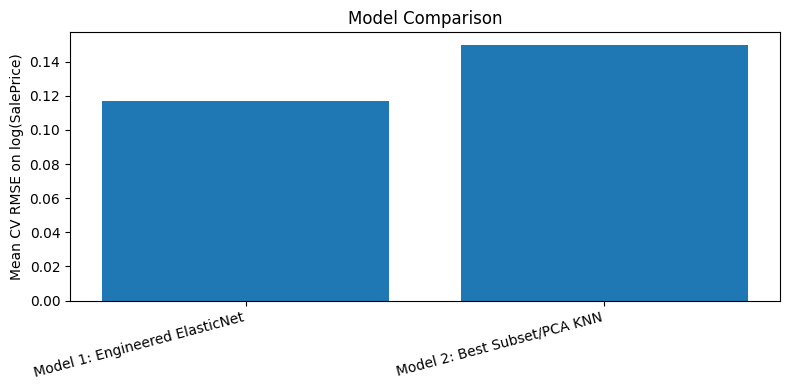

In [52]:
# Bar plot comparing mean CV RMSE of the two models
plt.figure(figsize=(8, 4))
plt.bar(results_summary["model"], results_summary["mean_cv_rmse_log"])
plt.xticks(rotation=15, ha="right")
plt.ylabel("Mean CV RMSE on log(SalePrice)")
plt.title("Model Comparison")
plt.tight_layout()
plt.show()

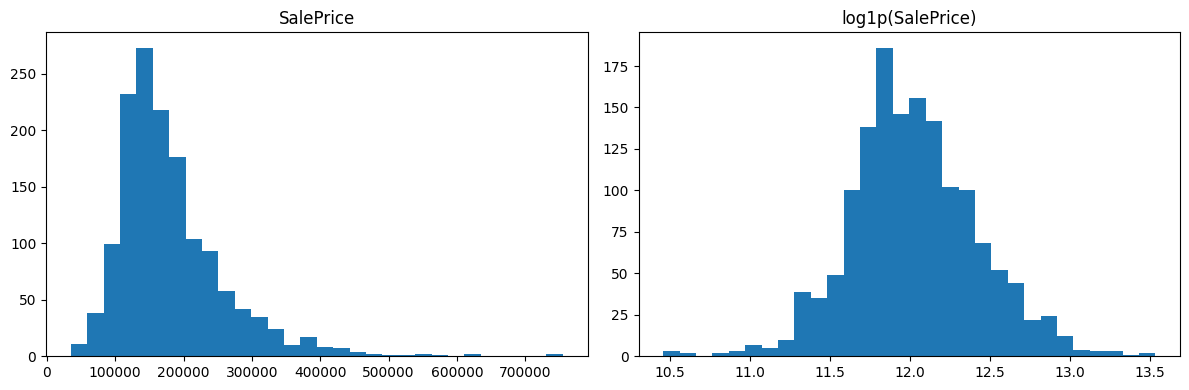

In [53]:
# Distribution of target on raw and log scale
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train["SalePrice"], bins=30)
axes[0].set_title("SalePrice")
axes[1].hist(np.log1p(train["SalePrice"]), bins=30)
axes[1].set_title("log1p(SalePrice)")
plt.tight_layout()
plt.show()